# Inferência — AnyNet FER+ no CK+

Carrega o modelo treinado no FER+ e avalia no CK+ para medir generalização.

## 1. Imports

In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Configuração

In [2]:
# ── Modelo treinado ───────────────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/models/jniorviana/anynetbestmodel/pytorch/default/1/anynet_fold_1.pth"  # ajusta o path

# ── Dataset CK+ ───────────────────────────────────────────────────────────────
CKP_DIR = "/kaggle/input/datasets/shuvoalok/ck-dataset"  # ajusta o path
# Estrutura esperada: CKP_DIR/anger/, CKP_DIR/contempt/, ...

BATCH_SIZE = 64
OUTPUT_DIR = "inference_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Classes do CK+ (como estão nas pastas)
CKP_CLASSES = ["anger", "contempt", "disgust", "fear", "happy", "sadness", "surprise"]

# Mapeamento CK+ → FER+ para análise de confusão
# (nomes diferentes mas mesma emoção)
CKP_TO_FERPLUS = {
    "anger"   : "angry",
    "contempt": "contempt",
    "disgust" : "disgust",
    "fear"    : "fear",
    "happy"   : "happy",
    "sadness" : "sad",
    "surprise": "suprise",   # typo original do FER+
}


## 3. Arquitetura AnyNet

In [3]:
class SEBlock(nn.Module):
    def __init__(self, ch, ratio=4):
        super().__init__()
        r = max(1, ch // ratio)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(r, ch, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)


class PlainConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, **kwargs):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
    def forward(self, x):
        return self.conv(x) + self.shortcut(x)


class MBConv(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, **kwargs):
        super().__init__()
        mid_ch  = in_ch * expand_ratio
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, mid_ch, kernel_size, stride=stride,
                      padding=padding, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            SEBlock(mid_ch),
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
    def forward(self, x):
        return self.conv(x) + self.shortcut(x)


class Stem(nn.Module):
    def __init__(self, out_ch=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.stem(x)


class AnyNetStage(nn.Module):
    def __init__(self, in_ch, out_ch, depth, block_type):
        super().__init__()
        blocks = []
        for i in range(depth):
            stride = 2 if i == 0 else 1
            blocks.append(block_type(in_ch if i == 0 else out_ch, out_ch, stride=stride))
        self.blocks = nn.Sequential(*blocks)
    def forward(self, x): return self.blocks(x)


class AnyNet(nn.Module):
    def __init__(self, num_stages, widths, depths, transition_stage, dropout, num_classes=8):
        super().__init__()
        self.stem = Stem(out_ch=32)
        stages, in_ch = [], 32
        for i in range(num_stages):
            block_type = MBConv if i >= transition_stage - 1 else PlainConv
            stages.append(AnyNetStage(in_ch, widths[i], depths[i], block_type))
            in_ch = widths[i]
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(widths[-1], num_classes),
        )
        last_stage = list(self.stages.children())[-1]
        last_block = list(last_stage.blocks.children())[-1]
        self.gradcam_target = last_block.conv[-1]

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.head(x)


## 4. Carrega o modelo

In [4]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

config  = checkpoint["config"]
classes = checkpoint["classes"]   # classes do FER+ — 8 classes

model = AnyNet(
    num_stages       = config["num_stages"],
    widths           = config["widths"],
    depths           = config["depths"],
    transition_stage = config["transition_stage"],
    dropout          = config["dropout"],
    num_classes      = len(classes),
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo carregado: {checkpoint['trial_id']}")
print(f"Config           : {config}")
print(f"Parâmetros       : {n_params:,}")
print(f"Classes FER+     : {classes}")
print(f"Best val F1      : {checkpoint['best_val_f1']:.4f}")


Modelo carregado: pc01_trial_31
Config           : {'num_stages': 3, 'widths': [192, 192, 208], 'depths': [3, 4, 4], 'transition_stage': 4, 'dropout': 0.310406}
Parâmetros       : 3,664,584
Classes FER+     : ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']
Best val F1      : 0.8988


## 5. Carrega o CK+

In [5]:
transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])


class CKPlusDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples   = []
        self.transform = transform
        # Percorre as pastas de classe
        for class_name in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for fname in os.listdir(class_path):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((
                        os.path.join(class_path, fname),
                        class_name,
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, class_name = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, class_name


ckp_dataset = CKPlusDataset(CKP_DIR, transform=transform_eval)
ckp_loader  = DataLoader(ckp_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Total de imagens CK+: {len(ckp_dataset)}")

# Distribuição por classe
from collections import Counter
dist = Counter(s[1] for s in ckp_dataset.samples)
print("\nDistribuição:")
for cls in CKP_CLASSES:
    print(f"  {cls:<12}: {dist.get(cls, 0):4d} imagens")


Total de imagens CK+: 981

Distribuição:
  anger       :  135 imagens
  contempt    :   54 imagens
  disgust     :  177 imagens
  fear        :   75 imagens
  happy       :  207 imagens
  sadness     :   84 imagens
  surprise    :  249 imagens


## 6. Inferência

In [6]:
@torch.no_grad()
def run_inference(model, loader, classes):
    model.eval()
    all_true_names  = []   # nome da classe real (CK+)
    all_pred_names  = []   # nome da classe predita (FER+)
    all_probs       = []   # probabilidades de cada classe

    for imgs, class_names in loader:
        imgs    = imgs.to(device)
        logits  = model(imgs)
        probs   = torch.softmax(logits, dim=1)
        preds   = logits.argmax(dim=1).cpu().numpy()

        all_true_names.extend(class_names)
        all_pred_names.extend([classes[p] for p in preds])
        all_probs.extend(probs.cpu().numpy())

    return all_true_names, all_pred_names, np.array(all_probs)


true_names, pred_names, probs = run_inference(model, ckp_loader, classes)

print(f"Inferência concluída: {len(true_names)} imagens")
print(f"\nExemplos:")
for i in range(5):
    print(f"  Real: {true_names[i]:<12} → Pred: {pred_names[i]}")


Inferência concluída: 981 imagens

Exemplos:
  Real: anger        → Pred: angry
  Real: anger        → Pred: neutral
  Real: anger        → Pred: neutral
  Real: anger        → Pred: neutral
  Real: anger        → Pred: contempt


## 7. Métricas — mapeamento CK+ → FER+

In [7]:
# Mapeia os nomes reais do CK+ para os nomes do FER+
true_mapped = [CKP_TO_FERPLUS[n] for n in true_names]

# Classes presentes no CK+ (no espaço do FER+)
ckp_in_ferplus = [CKP_TO_FERPLUS[c] for c in CKP_CLASSES]

acc    = accuracy_score(true_mapped, pred_names)
f1_mac = f1_score(true_mapped, pred_names, average="macro",
                  labels=ckp_in_ferplus, zero_division=0)
f1_wei = f1_score(true_mapped, pred_names, average="weighted",
                  labels=ckp_in_ferplus, zero_division=0)

print(f"Accuracy        : {acc:.4f}")
print(f"F1 Macro        : {f1_mac:.4f}")
print(f"F1 Weighted     : {f1_wei:.4f}")
print()
print(classification_report(
    true_mapped, pred_names,
    labels=ckp_in_ferplus,
    target_names=CKP_CLASSES,
    zero_division=0,
))


Accuracy        : 0.5525
F1 Macro        : 0.4243
F1 Weighted     : 0.5880

              precision    recall  f1-score   support

       anger       0.16      0.10      0.12       135
    contempt       0.00      0.00      0.00        54
     disgust       0.98      0.34      0.50       177
        fear       1.00      0.07      0.12        75
       happy       0.94      0.99      0.96       207
     sadness       0.33      0.29      0.31        84
    surprise       0.96      0.95      0.95       249

   micro avg       0.79      0.55      0.65       981
   macro avg       0.62      0.39      0.42       981
weighted avg       0.75      0.55      0.59       981



## 8. Matriz de confusão

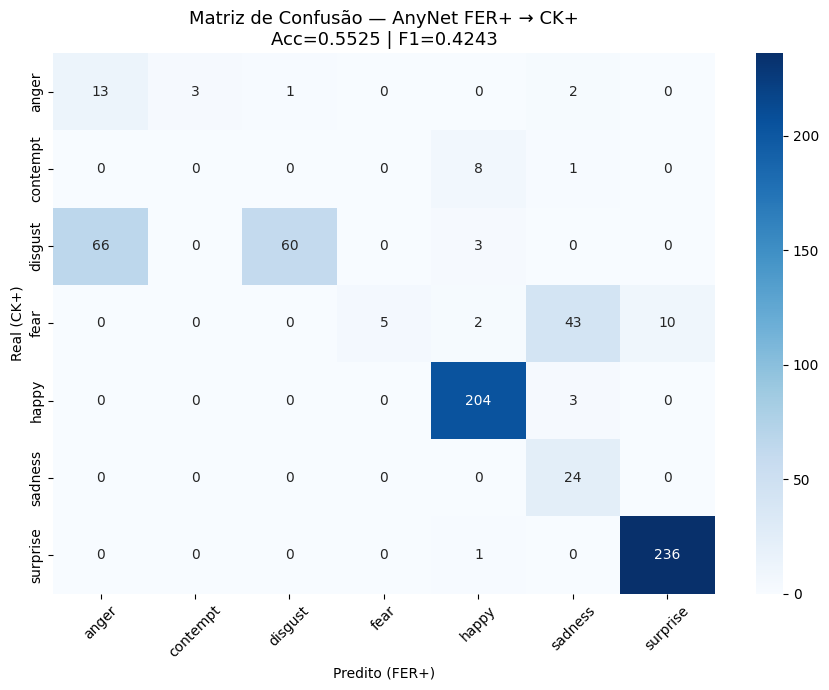

In [8]:
cm = confusion_matrix(true_mapped, pred_names,
                      labels=ckp_in_ferplus)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CKP_CLASSES,
    yticklabels=CKP_CLASSES,
    ax=ax,
)
ax.set_title(f"Matriz de Confusão — AnyNet FER+ → CK+\nAcc={acc:.4f} | F1={f1_mac:.4f}", fontsize=13)
ax.set_xlabel("Predito (FER+)")
ax.set_ylabel("Real (CK+)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_ckplus.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. Distribuição de predições por classe

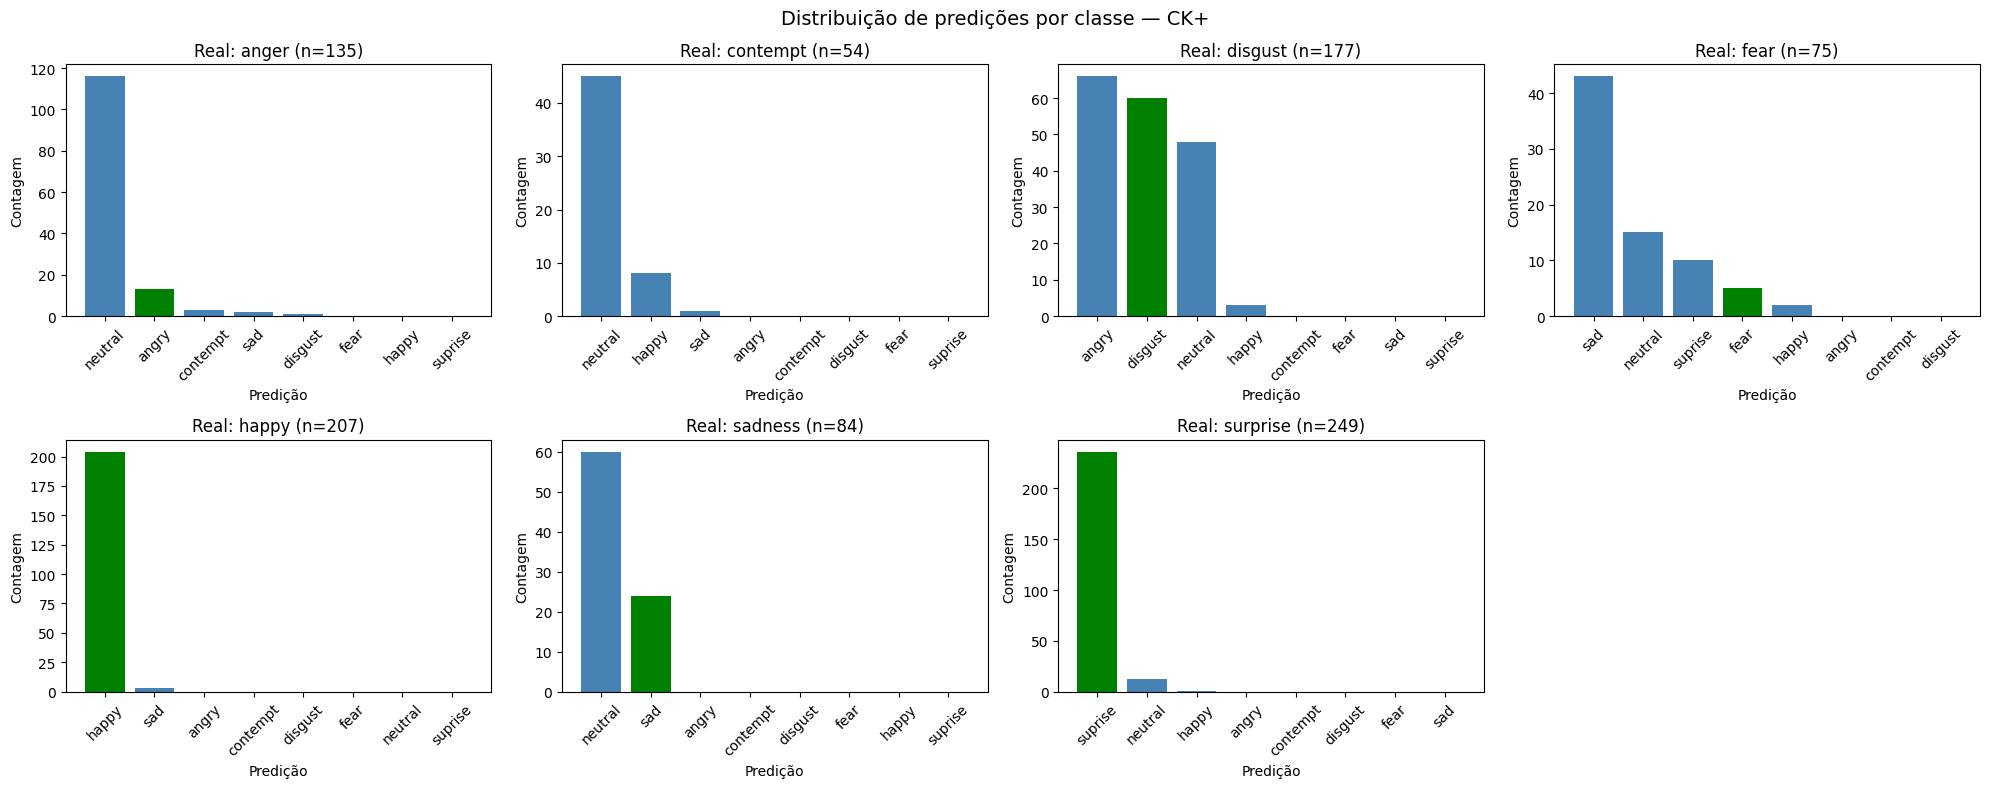

In [9]:
# Para cada classe real do CK+, mostra como o modelo distribuiu as predições
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax_idx, ckp_cls in enumerate(CKP_CLASSES):
    fer_cls = CKP_TO_FERPLUS[ckp_cls]

    # Filtra só as amostras dessa classe
    mask  = [t == fer_cls for t in true_mapped]
    preds = [p for p, m in zip(pred_names, mask) if m]

    if not preds:
        axes[ax_idx].axis("off")
        continue

    pred_dist = Counter(preds)
    sorted_classes = sorted(classes, key=lambda c: -pred_dist.get(c, 0))
    counts = [pred_dist.get(c, 0) for c in sorted_classes]

    colors = ["green" if c == fer_cls else "steelblue" for c in sorted_classes]
    axes[ax_idx].bar(sorted_classes, counts, color=colors)
    axes[ax_idx].set_title(f"Real: {ckp_cls} (n={len(preds)})")
    axes[ax_idx].set_xlabel("Predição")
    axes[ax_idx].set_ylabel("Contagem")
    axes[ax_idx].tick_params(axis="x", rotation=45)

# Esconde o último subplot (são 7 classes, 8 subplots)
axes[-1].axis("off")

plt.suptitle("Distribuição de predições por classe — CK+", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pred_distribution_ckplus.png"), dpi=150, bbox_inches="tight")
plt.show()


## 10. Exemplos visuais — acertos e erros

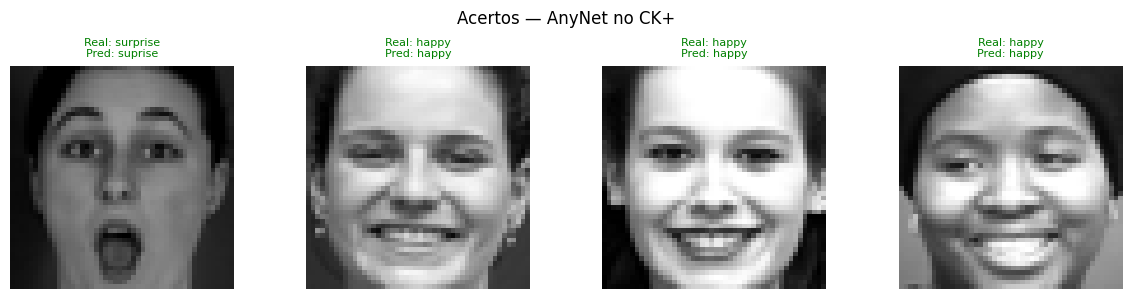

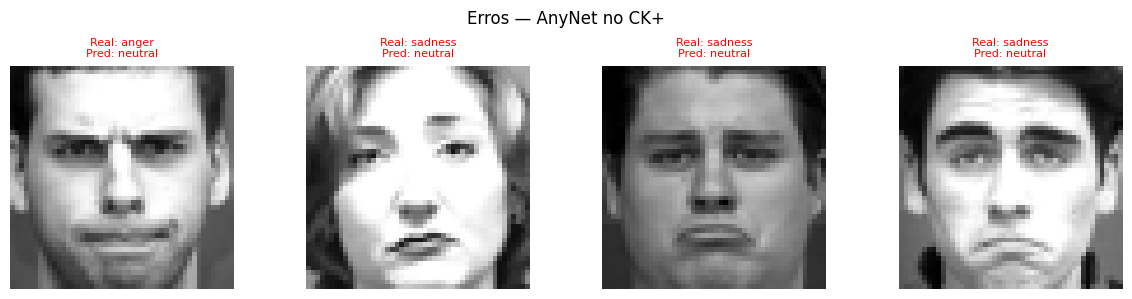

In [10]:
# Mostra 4 acertos e 4 erros aleatórios
correct_idx = [i for i, (t, p) in enumerate(zip(true_mapped, pred_names)) if t == p]
wrong_idx   = [i for i, (t, p) in enumerate(zip(true_mapped, pred_names)) if t != p]

mean = np.array([0.5, 0.5, 0.5])
std  = np.array([0.5, 0.5, 0.5])

def show_examples(indices, title, n=4):
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    sample = random.sample(indices, min(n, len(indices)))
    for ax, idx in zip(axes, sample):
        path, _ = ckp_dataset.samples[idx]
        img     = Image.open(path).convert("RGB").resize((48, 48))
        ax.imshow(img)
        ax.set_title(
            f"Real: {true_names[idx]}\nPred: {pred_names[idx]}",
            fontsize=8,
            color="green" if true_mapped[idx] == pred_names[idx] else "red",
        )
        ax.axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_").replace("—", "").strip() + ".png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()


show_examples(correct_idx, "Acertos — AnyNet no CK+")
show_examples(wrong_idx,   "Erros — AnyNet no CK+")


## 11. Salva resultados

In [11]:
results_df = pd.DataFrame({
    "path"      : [s[0] for s in ckp_dataset.samples],
    "true_ckp"  : true_names,
    "true_ferp" : true_mapped,
    "pred_ferp" : pred_names,
    "correct"   : [t == p for t, p in zip(true_mapped, pred_names)],
    **{f"prob_{c}": probs[:, i] for i, c in enumerate(classes)},
})

csv_path = os.path.join(OUTPUT_DIR, "inference_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"Resultados salvos: {csv_path}")
print(f"\nResumo final:")
print(f"  Total imagens : {len(results_df)}")
print(f"  Acertos       : {results_df['correct'].sum()}")
print(f"  Erros         : {(~results_df['correct']).sum()}")
print(f"  Accuracy      : {acc:.4f}")
print(f"  F1 Macro      : {f1_mac:.4f}")
print(f"  F1 Weighted   : {f1_wei:.4f}")


Resultados salvos: inference_output/inference_results.csv

Resumo final:
  Total imagens : 981
  Acertos       : 542
  Erros         : 439
  Accuracy      : 0.5525
  F1 Macro      : 0.4243
  F1 Weighted   : 0.5880
